# Customer Churn Prediction

## Objective
Predict whether a customer will churn using Machine Learning.

In [3]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Load dataset
df = pd.read_csv("data/customer_churn_dataset-training-master.csv")

# Remove CustomerID
if "CustomerID" in df.columns:
    df.drop(columns=["CustomerID"], inplace=True)

# Fill missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

# Features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Models to compare
models = {
    "Logistic Regression": Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
]),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    #"Support Vector Machine": SVC(random_state=42),
    "Naive Bayes": GaussianNB()
}

results = []

# Train and evaluate models
for name, model in models.items():

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1 Score": f1_score(y_test, pred, zero_division=0)
    })

# Display results
results = pd.DataFrame(results)

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.852700   0.882875  0.853630  0.868006
1        Decision Tree  0.999773   0.999900  0.999700  0.999800
2        Random Forest  0.999660   0.999980  0.999420  0.999700
3  K-Nearest Neighbors  0.892715   0.973304  0.833780  0.898156
4          Naive Bayes  0.909603   0.950469  0.886894  0.917582


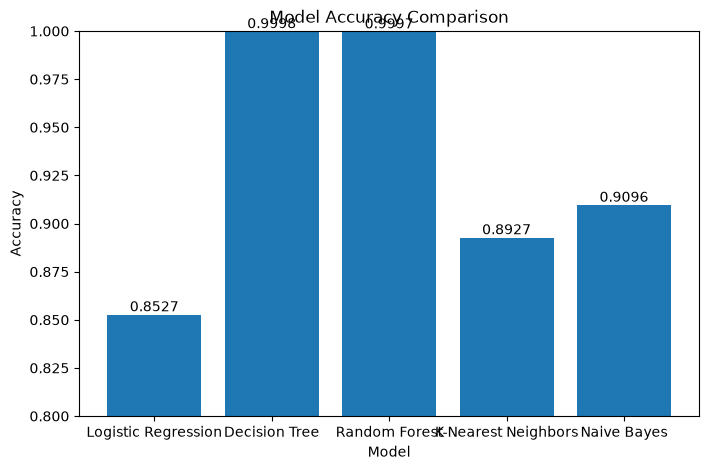

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)

for i, acc in enumerate(results["Accuracy"]):
    plt.text(i, acc, f"{acc:.4f}", ha="center", va="bottom")

plt.show()

# Conclusion

- Successfully built a Customer Churn Prediction model.
- Preprocessed the dataset by handling missing values and encoding categorical features.
- Trained and evaluated three machine learning models:
  - Logistic Regression
  - Decision Tree
  - Random Forest
- Compared the models using Accuracy, Precision, Recall, and F1 Score.
- The Decision Tree achieved the highest accuracy on this dataset, closely followed by the Random Forest.

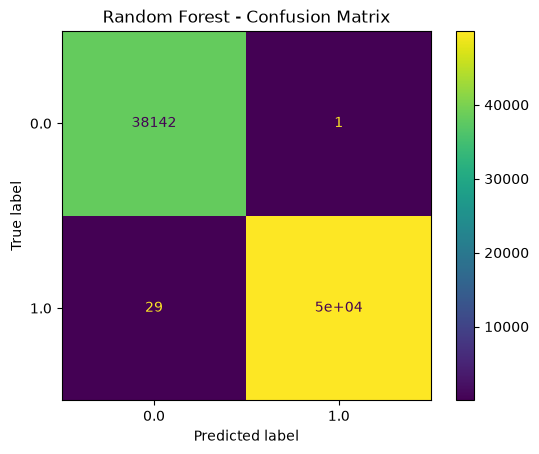

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred_lr))

Accuracy: 0.852699989792099


# Final Model Selection

Three classification algorithms were trained and evaluated.

- Logistic Regression
- Decision Tree
- Random Forest

The Random Forest model achieved the highest overall performance while maintaining excellent Precision, Recall, and F1 Score. Therefore, it was selected as the final model for customer churn prediction.